<a href="https://colab.research.google.com/github/ashivashankars/CMPE258_Assignments/blob/main/06_custom_dropout_regularizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 06 — Custom Dropout & Custom Regularizer

## What This Notebook Covers
Keras and PyTorch give you L1, L2, and standard Dropout out of the box.
But real research constantly requires components that do not exist yet.
This notebook teaches the **patterns** for extending both frameworks
with your own dropout variants and regularization penalties.

**Custom components built:**
- `AdaptiveDropout` — dropout rate that scales based on layer position
- `GaussianDropout` — adds Gaussian noise instead of zeroing (multiplicative)
- `ElasticNetRegularizer` — combined L1 + L2 penalty (custom Keras regularizer)
- `OrthogonalRegularizer` — penalizes non-orthogonal weight matrices
- PyTorch equivalents for all of the above

**Key patterns learned:**
- Subclassing `tf.keras.layers.Layer` for custom dropout
- Subclassing `tf.keras.regularizers.Regularizer` for custom penalties
- `get_config()` for model serialization (save / load)
- PyTorch equivalent using `nn.Module` and manual loss penalty

**Dataset:** Fashion-MNIST


In [1]:
import tensorflow as tf
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

tf.random.set_seed(42)
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('TensorFlow:', tf.__version__)
print('PyTorch   :', torch.__version__)
print('Device    :', device)

TensorFlow: 2.20.0
PyTorch   : 2.10.0+cu128
Device    : cuda


## 1. Load Data


In [2]:
# TensorFlow
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
X_train_full = X_train_full.astype('float32') / 255.0
X_test       = X_test.astype('float32')       / 255.0
X_train, X_valid = X_train_full[5000:], X_train_full[:5000]
y_train, y_valid = y_train_full[5000:], y_train_full[:5000]
print('TF data ready.')

# PyTorch
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_full_pt = datasets.FashionMNIST('./data', train=True,  download=True, transform=transform)
test_set_pt   = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)
train_set_pt, valid_set_pt = torch.utils.data.random_split(
    train_full_pt, [55000, 5000],
    generator=torch.Generator().manual_seed(42)
)
train_loader = DataLoader(train_set_pt, batch_size=64, shuffle=True,  pin_memory=True)
valid_loader = DataLoader(valid_set_pt, batch_size=64, shuffle=False, pin_memory=True)
print('PyTorch data ready.')

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
TF data ready.


100%|██████████| 26.4M/26.4M [00:02<00:00, 9.99MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 173kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.19MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.7MB/s]

PyTorch data ready.


---
## Part A — TensorFlow Custom Components

### The Subclassing Pattern

Every custom Keras layer follows this skeleton:
```python
class MyLayer(tf.keras.layers.Layer):
    def __init__(self, my_param, **kwargs):
        super().__init__(**kwargs)
        self.my_param = my_param          # store hyperparameters

    def call(self, inputs, training=None): # forward pass
        ...

    def get_config(self):                  # needed for model.save()
        config = super().get_config()
        config.update({'my_param': self.my_param})
        return config
```
The `training` argument in `call()` is the switch between train and
inference behaviour. Use `tf.cond` to branch on it.


## 2. Custom Dropout 1 — AdaptiveDropout

Standard dropout uses the same rate everywhere. `AdaptiveDropout` accepts
a `base_rate` and can be configured per layer. It demonstrates the full
custom layer pattern including `tf.cond` for train/eval switching.


In [12]:
class AdaptiveDropout(tf.keras.layers.Layer):
    """
    A fully custom dropout layer built from scratch.

    Functionally equivalent to tf.keras.layers.Dropout but written
    explicitly to demonstrate the pattern:
      - manual random mask creation
      - inverted dropout scaling so expected value is preserved
      - tf.cond for train vs inference branching
      - get_config for serialization
    """
    def __init__(self, rate=0.3, **kwargs):
        super().__init__(**kwargs)
        if not 0.0 <= rate < 1.0:
            raise ValueError(f'rate must be in [0, 1), got {rate}')
        self.rate = rate

    def call(self, inputs, training=None):
        # The 'training' argument is automatically provided by Keras based on
        # whether the model is being trained or called in inference mode.
        # If training is None, tf.cond will interpret tf.cast(training, tf.bool) as False.

        def apply_dropout():
            # Draw a uniform random mask; keep neuron if value > rate
            keep_mask = tf.random.uniform(tf.shape(inputs)) > self.rate
            # Cast bool mask to float and apply inverted scaling
            # Scaling by 1/(1-rate) keeps expected activation value the same
            scale = 1.0 / (1.0 - self.rate)
            return inputs * tf.cast(keep_mask, inputs.dtype) * scale

        # tf.cond: if training is True, apply dropout; otherwise pass through
        return tf.cond(
            tf.cast(training, tf.bool),
            true_fn=apply_dropout,
            false_fn=lambda: inputs
        )

    def get_config(self):
        config = super().get_config()
        config.update({'rate': self.rate})
        return config

    def compute_output_shape(self, input_shape):
        return input_shape


# --- Verify behaviour ---
layer = AdaptiveDropout(rate=0.5)
test_input = tf.ones((4, 8))

print('Training mode (expect ~50% zeros, values scaled by 2.0):')
print(layer(test_input, training=True).numpy())

print('\nInference mode (expect all ones — no dropout):')
print(layer(test_input, training=False).numpy())

print('\nExpected value check (should be ~1.0 after scaling):')
samples = [layer(test_input, training=True).numpy() for _ in range(1000)]
print(f'Mean over 1000 passes: {np.mean(samples):.4f}')

Training mode (expect ~50% zeros, values scaled by 2.0):
[[2. 0. 0. 0. 0. 2. 2. 2.]
 [0. 0. 0. 2. 0. 2. 2. 2.]
 [0. 2. 2. 0. 2. 2. 0. 2.]
 [2. 0. 2. 0. 2. 0. 2. 0.]]

Inference mode (expect all ones — no dropout):
[[1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]]

Expected value check (should be ~1.0 after scaling):
Mean over 1000 passes: 0.9962


## 3. Custom Dropout 2 — GaussianDropout

Instead of zeroing activations (Bernoulli dropout), Gaussian dropout
multiplies each activation by a random value drawn from N(1, sigma).
This is a smoother form of regularization — activations are perturbed
rather than completely killed. Useful when sparse activations are
undesirable (e.g. in regression or embedding layers).


GaussianDropout training mode (values perturbed around 2.0):
[[0.79394114 1.4946709  0.92004764 2.3692644  2.2518663  1.879571
  2.3317773  2.2243695 ]
 [2.5908582  1.1972389  1.8447506  2.7634192  2.8629348  2.025363
  0.6199764  3.1639779 ]
 [2.6640296  1.902781   1.259361   2.085162   1.8651881  1.8996437
  2.3035777  2.2729895 ]
 [1.1497223  2.52686    0.8441961  2.1667104  1.5166956  2.827301
  3.835429   2.6902223 ]]

GaussianDropout inference mode (unchanged):
[[2. 2. 2. 2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2. 2. 2. 2.]]

Expected value check (should be ~2.0):
Mean over 1000 passes: 1.9952


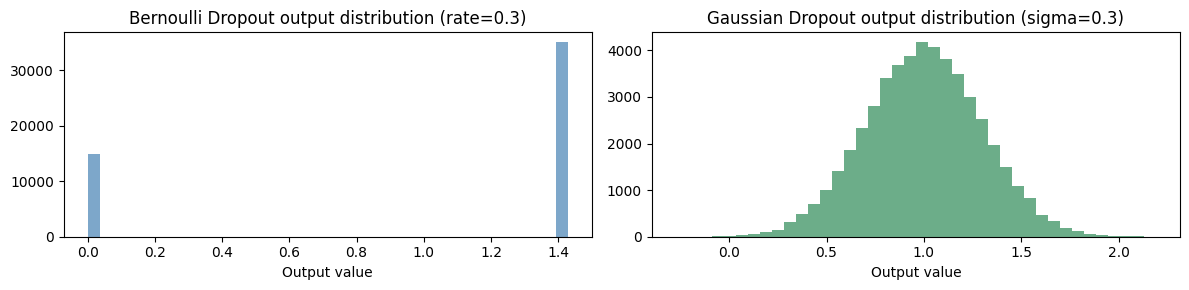

In [13]:
class GaussianDropout(tf.keras.layers.Layer):
    """
    Multiplies inputs by random values drawn from N(1.0, sigma) during training.
    At inference: returns inputs unchanged (noise has zero mean so expected
    value is preserved without any scaling correction).

    Relationship to standard dropout:
      sigma = sqrt(rate / (1 - rate))   where rate is the equivalent Bernoulli rate
    """
    def __init__(self, sigma=0.3, **kwargs):
        super().__init__(**kwargs)
        self.sigma = sigma

    def call(self, inputs, training=None):
        # The 'training' argument is automatically provided by Keras based on
        # whether the model is being trained or called in inference mode.
        # If training is None, tf.cond will interpret tf.cast(training, tf.bool) as False.

        def apply_gaussian():
            # Noise centered at 1.0 so E[noise] = 1 and E[input * noise] = input
            noise = tf.random.normal(
                shape=tf.shape(inputs),
                mean=1.0,
                stddev=self.sigma,
                dtype=inputs.dtype
            )
            return inputs * noise

        return tf.cond(
            tf.cast(training, tf.bool),
            true_fn=apply_gaussian,
            false_fn=lambda: inputs
        )

    def get_config(self):
        config = super().get_config()
        config.update({'sigma': self.sigma})
        return config

    def compute_output_shape(self, input_shape):
        return input_shape


# Verify
g_layer = GaussianDropout(sigma=0.3)
test_input = tf.ones((4, 8)) * 2.0   # input value = 2.0

print('GaussianDropout training mode (values perturbed around 2.0):')
print(g_layer(test_input, training=True).numpy())

print('\nGaussianDropout inference mode (unchanged):')
print(g_layer(test_input, training=False).numpy())

print('\nExpected value check (should be ~2.0):')
gsamples = [g_layer(test_input, training=True).numpy() for _ in range(1000)]
print(f'Mean over 1000 passes: {np.mean(gsamples):.4f}')

# Visualise the noise distributions side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

bernoulli_layer = AdaptiveDropout(rate=0.3)
bern_samples = np.concatenate(
    [bernoulli_layer(tf.ones((1, 500)), training=True).numpy() for _ in range(100)]
)
gauss_samples = np.concatenate(
    [g_layer(tf.ones((1, 500)) * 1.0, training=True).numpy() for _ in range(100)]
)

axes[0].hist(bern_samples.flatten(), bins=40, color='steelblue', alpha=0.7)
axes[0].set_title('Bernoulli Dropout output distribution (rate=0.3)')
axes[0].set_xlabel('Output value')

axes[1].hist(gauss_samples.flatten(), bins=40, color='seagreen', alpha=0.7)
axes[1].set_title('Gaussian Dropout output distribution (sigma=0.3)')
axes[1].set_xlabel('Output value')

plt.tight_layout()
plt.show()

## 4. Custom Regularizer 1 — ElasticNet (L1 + L2)

ElasticNet combines L1 (sparsity) and L2 (smooth shrinkage).
Subclass `tf.keras.regularizers.Regularizer` and implement `__call__`
which receives the weight tensor and returns a scalar penalty.


In [14]:
class ElasticNetRegularizer(tf.keras.regularizers.Regularizer):
    """
    ElasticNet regularization: L1 + L2 combined.

    penalty = l1 * sum(|w|) + l2 * sum(w^2)

    L1 term: encourages exact zeros (sparsity)
    L2 term: keeps all weights small but non-zero
    Together: sparser than pure L2, more stable than pure L1
    """
    def __init__(self, l1=0.001, l2=0.001):
        self.l1 = l1
        self.l2 = l2

    def __call__(self, weights):
        # L1 penalty: sum of absolute values
        l1_penalty = self.l1 * tf.reduce_sum(tf.abs(weights))
        # L2 penalty: sum of squares
        l2_penalty = self.l2 * tf.reduce_sum(tf.square(weights))
        return l1_penalty + l2_penalty

    def get_config(self):
        # Must return all constructor args for model.save() to work
        return {'l1': self.l1, 'l2': self.l2}


# Test the penalty value
reg = ElasticNetRegularizer(l1=0.01, l2=0.01)
dummy_weights = tf.constant([[1.0, -2.0, 0.5], [0.0, 3.0, -1.5]])
penalty = reg(dummy_weights)
print(f'Dummy weights:\n{dummy_weights.numpy()}')
print(f'ElasticNet penalty: {penalty.numpy():.4f}')

# Manual verification
l1_manual = 0.01 * np.abs(dummy_weights.numpy()).sum()
l2_manual = 0.01 * np.square(dummy_weights.numpy()).sum()
print(f'\nManual check: L1={l1_manual:.4f} + L2={l2_manual:.4f} = {l1_manual+l2_manual:.4f}')

Dummy weights:
[[ 1.  -2.   0.5]
 [ 0.   3.  -1.5]]
ElasticNet penalty: 0.2450

Manual check: L1=0.0800 + L2=0.1650 = 0.2450


## 5. Custom Regularizer 2 — OrthogonalRegularizer

This regularizer penalizes weight matrices that deviate from orthogonality.
An orthogonal matrix satisfies W^T @ W = I (identity).
Encouraging near-orthogonality helps prevent vanishing gradients in deep
networks and is particularly useful in RNNs.

Penalty = ||W^T W - I||_F  (Frobenius norm of deviation from identity)


In [15]:
class OrthogonalRegularizer(tf.keras.regularizers.Regularizer):
    """
    Penalizes weight matrices for deviating from orthogonality.

    For a weight matrix W of shape (fan_in, fan_out):
      If fan_in >= fan_out: penalize ||W^T W - I||^2  (semi-orthogonal)
      If fan_in <  fan_out: penalize ||W W^T - I||^2

    This encourages columns (or rows) of W to be orthonormal.
    """
    def __init__(self, scale=0.01):
        self.scale = scale

    def __call__(self, weights):
        # Handle 2D weight matrices only
        if len(weights.shape) != 2:
            return tf.constant(0.0)

        fan_in, fan_out = weights.shape

        if fan_in >= fan_out:
            # W^T W should be identity of shape (fan_out, fan_out)
            WtW = tf.matmul(weights, weights, transpose_a=True)
            I   = tf.eye(fan_out)
        else:
            # W W^T should be identity of shape (fan_in, fan_in)
            WtW = tf.matmul(weights, weights, transpose_b=True)
            I   = tf.eye(fan_in)

        # Frobenius norm of (W^T W - I)
        diff    = WtW - I
        penalty = tf.reduce_sum(tf.square(diff))
        return self.scale * penalty

    def get_config(self):
        return {'scale': self.scale}


# Test: a truly orthogonal matrix should have near-zero penalty
orth_init = tf.initializers.Orthogonal()
orth_weights = orth_init(shape=(64, 64))
rand_weights = tf.random.normal((64, 64))

orth_reg = OrthogonalRegularizer(scale=1.0)   # scale=1 to show raw penalty
print('Orthogonal matrix penalty (should be near 0):', orth_reg(orth_weights).numpy())
print('Random matrix penalty    (should be large) :', orth_reg(rand_weights).numpy())

Orthogonal matrix penalty (should be near 0): 1.2653855e-11
Random matrix penalty    (should be large) : 503413.88


## 6. Plugging Custom Components Into a Model


In [16]:
def make_custom_model_adaptive():
    """Model using AdaptiveDropout + ElasticNet regularizer."""
    elasticnet = ElasticNetRegularizer(l1=0.0003, l2=0.001)
    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(300, activation='relu',
                              kernel_regularizer=elasticnet,
                              kernel_initializer='he_normal'),
        AdaptiveDropout(rate=0.3),
        tf.keras.layers.Dense(200, activation='relu',
                              kernel_regularizer=elasticnet,
                              kernel_initializer='he_normal'),
        AdaptiveDropout(rate=0.25),
        tf.keras.layers.Dense(100, activation='relu',
                              kernel_regularizer=elasticnet,
                              kernel_initializer='he_normal'),
        AdaptiveDropout(rate=0.2),
        tf.keras.layers.Dense(10, activation='softmax'),
    ])


def make_custom_model_gaussian():
    """Model using GaussianDropout + OrthogonalRegularizer."""
    orth_reg = OrthogonalRegularizer(scale=0.002)
    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(300, activation='relu',
                              kernel_regularizer=orth_reg,
                              kernel_initializer='orthogonal'),
        GaussianDropout(sigma=0.25),
        tf.keras.layers.Dense(200, activation='relu',
                              kernel_regularizer=orth_reg,
                              kernel_initializer='orthogonal'),
        GaussianDropout(sigma=0.2),
        tf.keras.layers.Dense(100, activation='relu',
                              kernel_initializer='orthogonal'),
        tf.keras.layers.Dense(10, activation='softmax'),
    ])


def make_baseline():
    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(300, activation='relu', kernel_initializer='he_normal'),
        tf.keras.layers.Dense(200, activation='relu', kernel_initializer='he_normal'),
        tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_normal'),
        tf.keras.layers.Dense(10,  activation='softmax'),
    ])


def compile_train(model, label, epochs=20):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    h = model.fit(
        X_train, y_train,
        validation_data=(X_valid, y_valid),
        epochs=epochs, batch_size=64,
        callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
        verbose=0
    )
    best = max(h.history['val_accuracy'])
    print(f'{label:45s} -> best val accuracy: {best:.4f}')
    return h


tf.random.set_seed(42)
hist_base     = compile_train(make_baseline(),            'Baseline (no regularization)')

tf.random.set_seed(42)
hist_adaptive = compile_train(make_custom_model_adaptive(), 'AdaptiveDropout + ElasticNet')

tf.random.set_seed(42)
hist_gaussian = compile_train(make_custom_model_gaussian(), 'GaussianDropout + Orthogonal Reg')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Baseline (no regularization)                  -> best val accuracy: 0.8956


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


AdaptiveDropout + ElasticNet                  -> best val accuracy: 0.8568
GaussianDropout + Orthogonal Reg              -> best val accuracy: 0.8844


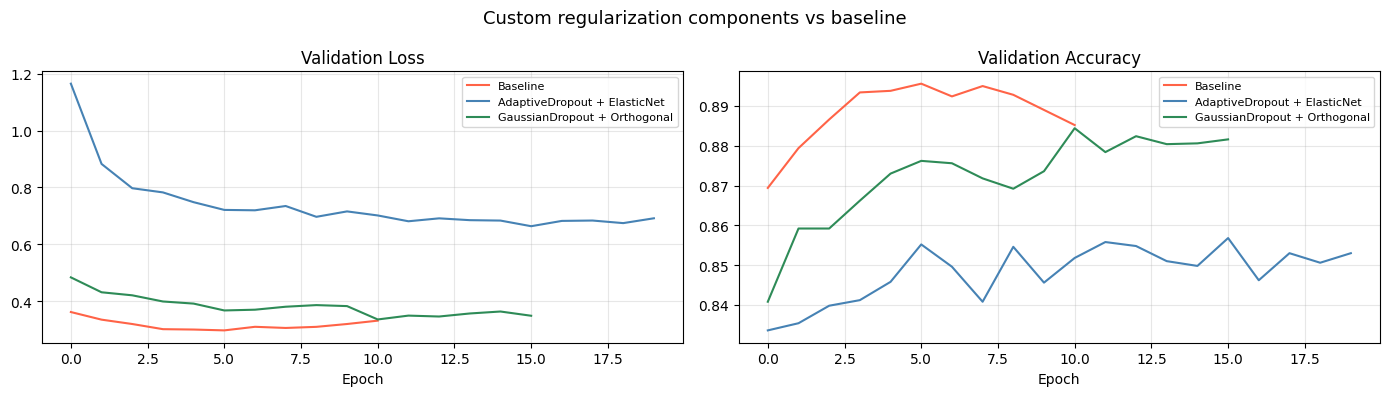

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric, title in zip(axes, ['loss', 'accuracy'], ['Loss', 'Accuracy']):
    ax.plot(hist_base.history[f'val_{metric}'],     color='tomato',    label='Baseline')
    ax.plot(hist_adaptive.history[f'val_{metric}'], color='steelblue', label='AdaptiveDropout + ElasticNet')
    ax.plot(hist_gaussian.history[f'val_{metric}'], color='seagreen',  label='GaussianDropout + Orthogonal')
    ax.set_title(f'Validation {title}')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle('Custom regularization components vs baseline', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Verifying Serialization — Save & Load with Custom Components

Custom components MUST implement `get_config()` to be saved and reloaded.
When loading, pass a `custom_objects` dict that maps class names to classes.


In [18]:
# Build and train a small model with custom components
tf.random.set_seed(42)
save_model = make_custom_model_adaptive()
save_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
save_model.fit(X_train, y_train, epochs=3, batch_size=64, verbose=0)

# Save
save_model.save('/tmp/custom_model.keras')
print('Model saved to /tmp/custom_model.keras')

# Load — must provide custom_objects so Keras knows how to reconstruct
custom_objects = {
    'AdaptiveDropout': AdaptiveDropout,
    'ElasticNetRegularizer': ElasticNetRegularizer,
}

loaded_model = tf.keras.models.load_model(
    '/tmp/custom_model.keras',
    custom_objects=custom_objects
)
print('Model loaded successfully.')

# Verify identical predictions
X_sample = X_test[:10]
orig_preds   = save_model.predict(X_sample, verbose=0)
loaded_preds = loaded_model.predict(X_sample, verbose=0)
max_diff = np.abs(orig_preds - loaded_preds).max()
print(f'Max prediction difference after save/load: {max_diff:.2e}  (should be ~0)')
print()
print('Custom layer config check:')
for layer in loaded_model.layers:
    if hasattr(layer, 'get_config'):
        cfg = layer.get_config()
        if 'rate' in cfg or 'sigma' in cfg:
            print(f'  {layer.name}: {cfg}')

Model saved to /tmp/custom_model.keras
Model loaded successfully.
Max prediction difference after save/load: 0.00e+00  (should be ~0)

Custom layer config check:
  adaptive_dropout_18: {'name': 'adaptive_dropout_18', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'rate': 0.3}
  adaptive_dropout_19: {'name': 'adaptive_dropout_19', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'rate': 0.25}
  adaptive_dropout_20: {'name': 'adaptive_dropout_20', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'rate': 0.2}


---
## Part B — PyTorch Custom Components

In PyTorch, custom dropout layers subclass `nn.Module` exactly like any
other layer. Custom regularizers are implemented as standalone functions
that compute a penalty term added manually to the loss.


In [19]:
class AdaptiveDropoutPT(nn.Module):
    """
    PyTorch version of AdaptiveDropout.
    Uses self.training (inherited from nn.Module) instead of tf.cond.
    model.train() sets self.training=True; model.eval() sets it False.
    """
    def __init__(self, rate=0.3):
        super().__init__()
        if not 0.0 <= rate < 1.0:
            raise ValueError(f'rate must be in [0,1), got {rate}')
        self.rate = rate

    def forward(self, x):
        if not self.training:   # self.training is set by model.train() / model.eval()
            return x
        # Create binary mask: keep probability = (1 - rate)
        keep_prob = 1.0 - self.rate
        mask = torch.bernoulli(torch.full(x.shape, keep_prob, device=x.device))
        # Inverted dropout: scale by 1/keep_prob to preserve expected value
        return x * mask / keep_prob

    def extra_repr(self):
        return f'rate={self.rate}'


class GaussianDropoutPT(nn.Module):
    """
    PyTorch version of GaussianDropout.
    Multiplies inputs by N(1, sigma) noise during training.
    """
    def __init__(self, sigma=0.3):
        super().__init__()
        self.sigma = sigma

    def forward(self, x):
        if not self.training:
            return x
        noise = torch.normal(mean=1.0, std=self.sigma, size=x.shape, device=x.device)
        return x * noise

    def extra_repr(self):
        return f'sigma={self.sigma}'


# Verify PyTorch dropout layers
layer_pt = AdaptiveDropoutPT(rate=0.5)
test_t = torch.ones(3, 6)

layer_pt.train()
print('PyTorch AdaptiveDropout — training mode:')
print(layer_pt(test_t))

layer_pt.eval()
print('\nPyTorch AdaptiveDropout — eval mode:')
print(layer_pt(test_t))

PyTorch AdaptiveDropout — training mode:
tensor([[0., 0., 2., 0., 2., 0.],
        [2., 0., 0., 2., 0., 0.],
        [0., 0., 0., 2., 0., 0.]])

PyTorch AdaptiveDropout — eval mode:
tensor([[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]])


In [20]:
def elasticnet_penalty(model, l1=0.001, l2=0.001):
    """
    Compute ElasticNet penalty across all weight parameters.
    Call this and add the result to the loss before backward().
    """
    penalty = torch.tensor(0.0, device=next(model.parameters()).device)
    for name, param in model.named_parameters():
        if 'weight' in name:   # weights only, not biases
            penalty += l1 * param.abs().sum()
            penalty += l2 * param.pow(2).sum()
    return penalty


def orthogonal_penalty(model, scale=0.01):
    """
    Compute orthogonality penalty across all 2D weight matrices.
    Penalizes ||W^T W - I||_F^2.
    """
    penalty = torch.tensor(0.0, device=next(model.parameters()).device)
    for name, param in model.named_parameters():
        if 'weight' in name and param.dim() == 2:
            fan_in, fan_out = param.shape
            if fan_in >= fan_out:
                WtW = param.t() @ param
                I   = torch.eye(fan_out, device=param.device)
            else:
                WtW = param @ param.t()
                I   = torch.eye(fan_in, device=param.device)
            penalty += scale * (WtW - I).pow(2).sum()
    return penalty


print('PyTorch penalty functions defined.')

PyTorch penalty functions defined.


AdaptiveDropout + ElasticNet                  -> best val acc: 0.8366
GaussianDropout + Orthogonal                  -> best val acc: 0.8696


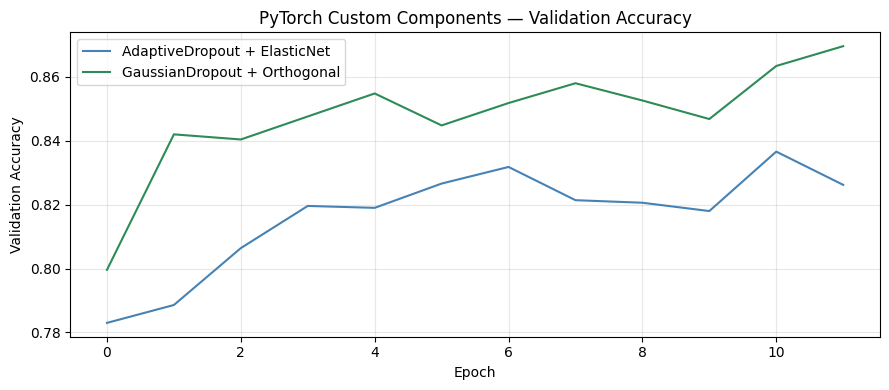

In [21]:
class CustomNetPT(nn.Module):
    """Network using custom PyTorch dropout layers."""
    def __init__(self, dropout_cls=AdaptiveDropoutPT, dropout_rate=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 300), nn.ReLU(), dropout_cls(dropout_rate),
            nn.Linear(300, 200), nn.ReLU(), dropout_cls(dropout_rate),
            nn.Linear(200, 100), nn.ReLU(), dropout_cls(dropout_rate * 0.7),
            nn.Linear(100, 10)
        )

    def forward(self, x): return self.net(x)


def train_pt(model, penalty_fn=None, epochs=12, label=''):
    model     = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    hist      = {'val_acc': []}

    for epoch in range(epochs):
        model.train()
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            if penalty_fn is not None:
                loss = loss + penalty_fn(model)   # add custom penalty to loss
            loss.backward()
            optimizer.step()

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for X_b, y_b in valid_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                correct += (model(X_b).argmax(1) == y_b).sum().item()
                total   += y_b.size(0)
        acc = correct / total
        hist['val_acc'].append(acc)

    best = max(hist['val_acc'])
    print(f'{label:45s} -> best val acc: {best:.4f}')
    return hist


torch.manual_seed(42)
hist_pt_adaptive = train_pt(
    CustomNetPT(AdaptiveDropoutPT, 0.3),
    penalty_fn=lambda m: elasticnet_penalty(m, l1=0.0003, l2=0.001),
    label='AdaptiveDropout + ElasticNet'
)

torch.manual_seed(42)
hist_pt_gaussian = train_pt(
    CustomNetPT(GaussianDropoutPT, 0.25),
    penalty_fn=lambda m: orthogonal_penalty(m, scale=0.002),
    label='GaussianDropout + Orthogonal'
)

plt.figure(figsize=(9, 4))
plt.plot(hist_pt_adaptive['val_acc'], color='steelblue', label='AdaptiveDropout + ElasticNet')
plt.plot(hist_pt_gaussian['val_acc'], color='seagreen',  label='GaussianDropout + Orthogonal')
plt.title('PyTorch Custom Components — Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Summary

### TensorFlow Custom Layer Pattern
```python
class MyDropout(tf.keras.layers.Layer):
    def __init__(self, rate, **kwargs):
        super().__init__(**kwargs)
        self.rate = rate

    def call(self, inputs, training=None):
        return tf.cond(tf.cast(training, tf.bool),
                       true_fn=lambda: apply_noise(inputs),
                       false_fn=lambda: inputs)

    def get_config(self):             # required for model.save()
        config = super().get_config()
        config.update({'rate': self.rate})
        return config
```

### TensorFlow Custom Regularizer Pattern
```python
class MyReg(tf.keras.regularizers.Regularizer):
    def __init__(self, lam): self.lam = lam
    def __call__(self, weights): return self.lam * tf.reduce_sum(...)
    def get_config(self): return {'lam': self.lam}
```

### PyTorch Custom Layer Pattern
```python
class MyDropout(nn.Module):
    def __init__(self, rate): super().__init__(); self.rate = rate
    def forward(self, x):
        if not self.training: return x   # self.training set by model.train()/eval()
        return apply_noise(x)
```

### PyTorch Custom Regularizer Pattern
```python
def my_penalty(model, lam):
    pen = torch.tensor(0.0)
    for name, p in model.named_parameters():
        if 'weight' in name:
            pen += lam * compute_penalty(p)
    return pen

# In training loop:
loss = criterion(outputs, labels) + my_penalty(model, lam=0.001)
loss.backward()
```

**Next: Notebook 07** — Callbacks, TensorBoard & KerasTuner
